# Loss Function

손실함수는 모델의 예측과 실제 정답 사이의 차이를 수치로 나타내는 기준이다.

모델은 단순히 예측값을 만드는 데서 끝나는 것이 아니라, 예측이 정답과 얼마나 다른지를 계산하고, 그 차이를 줄이는 방향으로 학습을 진행한다.

딥러닝 학습의 흐름:
- 입력 데이터가 모델을 통과해 예측값을 만든다.
- 예측값과 실제 정답을 비교한다.
- 손실함수로 오차를 수치화한다.
- 그 손실을 줄이는 방향으로 가중치를 업데이트한다.

## loss와 metric의 차이

손실함수(loss)와 평가지표(metric)는 비슷해 보이지만 역할이 다르다.

- loss: 모델이 학습할 때 직접 줄이려는 값
- metric: 사람이 모델 성능을 해석할 때 보는 값

분류 문제:
- loss: Binary Cross Entropy, Cross Entropy
- metric: Accuracy, Precision, Recall, F1-score

회귀 문제:
- loss: MSE, MAE, Huber
- metric: RMSE, MAE, R²

## 1. 이진분류 손실함수

이진분류에서는 정답이 보통 0 또는 1로 주어진다.

출력층에서 sigmoid를 사용하면 모델의 출력은 0~1 사이의 확률처럼 해석할 수 있다.

이때 손실함수는 예측 확률이 실제 정답과 얼마나 잘 맞는지를 계산해야 한다.

대표적인 손실함수는 `Binary Cross Entropy(BCE)`이다.

$$
\text{Loss} = -\left[y \cdot \log(p) + (1 - y) \cdot \log(1 - p)\right]
$$
- $y$: 실제 값 (0 또는 1)
- $p$: 예측 확률 (0과 1 사이)

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

y_true = torch.tensor([1., 1., 0., 0.])
y_pred_good = torch.tensor([0.95, 0.90, 0.10, 0.05])    # 정답과 가까운 경우
y_pred_bad = torch.tensor([0.10, 0.20, 0.80, 0.90])     # 정답과 멀어진 경우

# log에 0이 들어가면 연산 문제가 생기므로 아주 작은 값을 더해준다
eps = 1e-7

def binary_cross_entropy_manual(y_true, y_prob):
    return -(y_true * torch.log(y_prob + eps) + (1 - y_true) * torch.log(1 - y_prob + eps)).mean()

print('good predictions BCE : ', binary_cross_entropy_manual(y_true, y_pred_good))
print('bad predictions BCE : ', binary_cross_entropy_manual(y_true, y_pred_bad))

good predictions BCE :  tensor(0.0783)
bad predictions BCE :  tensor(1.9560)


In [2]:
# Pytorch의 BCELoss로 비교

bce = nn.BCELoss()

print('good predictions BCE : ', bce(y_pred_good, y_true))
print('bad predictions BCE : ', bce(y_pred_bad, y_true))

good predictions BCE :  tensor(0.0783)
bad predictions BCE :  tensor(1.9560)


### BCEWithLogitsLoss

실무와 실습에서는 `BCEWithLogitsLoss`를 더 자주 사용하는 경우가 많다.

이 손실함수는
- 모델 출력이 아직 sigmoid를 통과하지 않은 값(logit)이어도 사용할 수 있고
- 내부적으로 sigmoid와 BCE 계산을 함께 처리해 수치적으로 더 안정적이다.

즉,
- sigmoid를 이미 적용한 확률 → BCELoss
- sigmoid를 적용하기 전의 logit → BCEWithLogitsLoss

In [3]:
# logits : sigmoid를 거치기 전의 원래 출력값
logits_good = torch.tensor([3.0, 2.2, -2.0, -3.1])
logits_bad = torch.tensor([-2.0, -1.5, 1.8, 2.5])

bce_logits = nn.BCEWithLogitsLoss()

print('BCEWithLogitsLoss good : ', bce_logits(logits_good, y_true))
print('BCEWithLogitsLoss bad : ', bce_logits(logits_bad, y_true))

BCEWithLogitsLoss good :  tensor(0.0812)
BCEWithLogitsLoss bad :  tensor(2.0901)


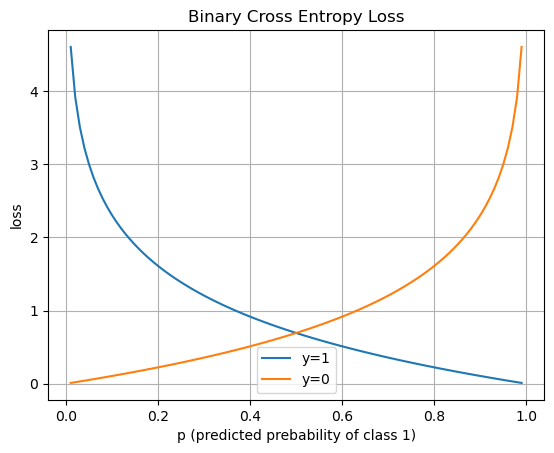

In [4]:
# Binary Cross Entropy Loss 시각화
# p : 모델이 1 클래스라고 예측한 확률
p = torch.linspace(0.01, 0.99, 100)

# 정답이 1인 경우 BCE Loss : -log(p)
bce_y1 = -torch.log(p)

# 정답이 0인 경우의 BCE Loss : -log(1-p)
bce_y2 = -torch.log(1 - p)

# numpy 변환
p_np = p.numpy()
bce_y1_np = bce_y1.numpy()
bce_y2_np = bce_y2.numpy()

plt.plot(p_np, bce_y1_np, label='y=1')
plt.plot(p_np, bce_y2_np, label='y=0')

plt.title("Binary Cross Entropy Loss")
plt.xlabel("p (predicted prebability of class 1)")
plt.ylabel("loss")
plt.legend()
plt.grid()
plt.show()

## 2. 다중분류 손실함수

다중분류에서는 클래스가 3개 이상일 수 있다.

이 경우 출력층에서는 클래스 수만큼 점수(logits)가 나오고, softmax를 적용하면 각 클래스에 대한 확률처럼 해석할 수 있다.

대표적인 손실함수는 `Cross Entropy`이다.

$$
\text{Loss} = -\log(\text{softmax}(\text{logits})[y])
$$

**수식 전체**

$$
\text{Loss} = -\log\left( \frac{e^{z_y}}{\sum_{j} e^{z_j}} \right)
$$

* $z = [z_0, z_1, ..., z_k]$: 각 클래스에 대한 모델의 출력값 (logits)
* $z_y$: 정답 클래스 $y$에 해당하는 로짓 값
* $\sum_j e^{z_j}$: 모든 클래스에 대한 softmax 분모

In [7]:
# 정답 클래스 인덱스(0부터 시작)
y_true_multi = torch.tensor([1, 0])

# softmax를 이미 거친 확률이라고 가정
prob_good = torch.tensor([[0.05, 0.90, 0.05], [0.85, 0.10, 0.05]])
prob_bad = torch.tensor([[0.60, 0.20, 0.20], [0.30, 0.35, 0.35]])

def cross_entropy_manual(y_true, y_prob):
    selected = y_prob[torch.arange(len(y_true)), y_true]
    return -(torch.log(selected + 1e-7)).mean()

print('good predictions cross entropy : ', cross_entropy_manual(y_true_multi, prob_good))
print('bad predictions cross entropy : ', cross_entropy_manual(y_true_multi, prob_bad))

good predictions cross entropy :  tensor(0.1339)
bad predictions cross entropy :  tensor(1.4067)


In [8]:
# Pytorch의 CrossEntropyLoss는 softmax 확률이 아니라 logits을 직접 받는 경우가 일반적이다
logits_good_multi = torch.tensor([[0.2, 3.0, 0.1], [2.8, 0.3, -0.2]])
logits_bad_multi = torch.tensor([[1.5, 0.4, 0.3], [0.2, 0.3, 0.4]])

ce = nn.CrossEntropyLoss()

print('CrossEntropyLoss good : ', ce(logits_good_multi, y_true_multi))
print('CrossEntropyLoss bad : ', ce(logits_bad_multi, y_true_multi))

CrossEntropyLoss good :  tensor(0.1167)
CrossEntropyLoss bad :  tensor(1.3965)


## 3. 회귀 손실함수

회귀에서는 정답이 연속형 수치다.

예를 들어 집값, 온도, 매출 같은 값을 예측할 때는 예측값과 실제값의 차이를 수치적으로 비교해야 한다.

### 대표적인 회귀 손실함수

1. MSE(Mean Squared Error)
- 오차를 제곱해 평균낸다.
- 큰 오차에 더 민감하다.

$$
\text{MSELoss} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

2. MAE(Mean Absolute Error)
- 오차의 절댓값을 평균낸다.
- 이상치에 상대적으로 덜 민감하다.

$$
\text{MAELoss} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

3. Huber Loss(Smooth L1 Loss)
- 작은 오차에서는 MSE처럼, 큰 오차에서는 MAE처럼 동작하는 절충형 손실함수이다.

$$
\text{HuberLoss}(y_i, \hat{y}_i) =
\begin{cases}
\frac{1}{2}(y_i - \hat{y}_i)^2 & \text{if } |y_i - \hat{y}_i| \leq \delta \\
\delta \cdot \left( |y_i - \hat{y}_i| - \frac{1}{2}\delta \right) & \text{otherwise}
\end{cases}
$$

In [10]:
y_true_reg = torch.tensor([100.0, 150.0, 200.0, 250.0])
y_pred_good = torch.tensor([102.0, 148.0, 198.0, 252.0])
y_pred_bad = torch.tensor([80.0, 120.0, 260.0, 320.0])

mse = nn.MSELoss()
mae = nn.L1Loss()
huber = nn.SmoothL1Loss(beta=1.0)

print('MSE good', mse(y_pred_good, y_true_reg))
print('MSE good', mse(y_pred_bad, y_true_reg))

print('MAE good', mae(y_pred_good, y_true_reg))
print('MAE good', mae(y_pred_bad, y_true_reg))

print('Huber good', huber(y_pred_good, y_true_reg))
print('Huber good', huber(y_pred_bad, y_true_reg))

MSE good tensor(4.)
MSE good tensor(2450.)
MAE good tensor(2.)
MAE good tensor(45.)
Huber good tensor(1.5000)
Huber good tensor(44.5000)


## 정리

- 손실함수는 예측과 정답의 차이를 수치로 나타내는 기준이다.
- 모델은 이 손실을 줄이는 방향으로 학습한다.
- 문제 유형에 따라 적절한 손실함수가 다르다.
- loss는 학습 기준이고, metric은 성능 해석 기준이다.

지금까지는 손실값을 계산하는 기준을 보았다.

그런데 모델이 손실을 줄이려면, 손실이 가중치에 따라 어떻게 변하는지를 알아야 한다.

이어서 미분과 기울기 개념을 통해 손실을 줄이는 방향을 어떻게 찾는지 살펴본다.